<a href="https://colab.research.google.com/github/MehulCodr/SEM-5-ML-Labs/blob/main/MLLabAssignment1_MehulGupta_24CS282.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn

#Loading the Iris Dataset
loaded the iris dataset and printed its description as well as the feature vectors and the target vectors


In [3]:
from sklearn.datasets import load_iris
import sklearn
dataset = load_iris()

print(dataset.DESCR)

features = dataset.data
target = dataset.target

print(features)
print(target)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

#Creating the SNS pairplots of the Iris Dataset

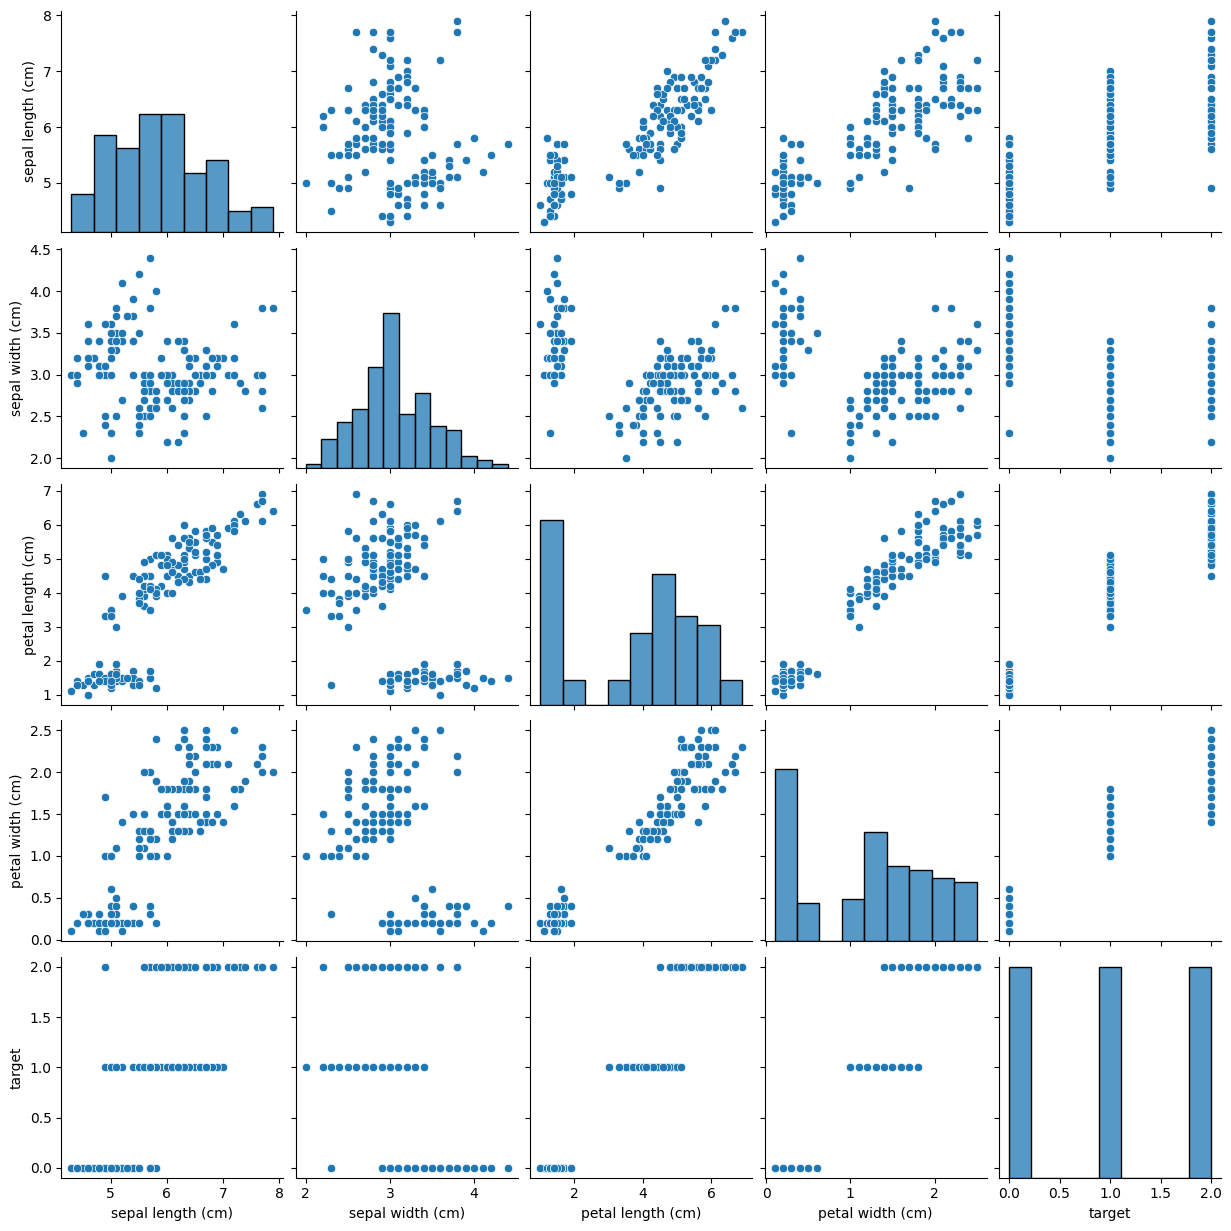

In [4]:
from seaborn.axisgrid import pd
from seaborn import pairplot, displot
ds_pandas = pd.DataFrame(features, columns=dataset.feature_names)
ds_pandas['target'] = target
pairplot(ds_pandas)

In [5]:
ds_pandas.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


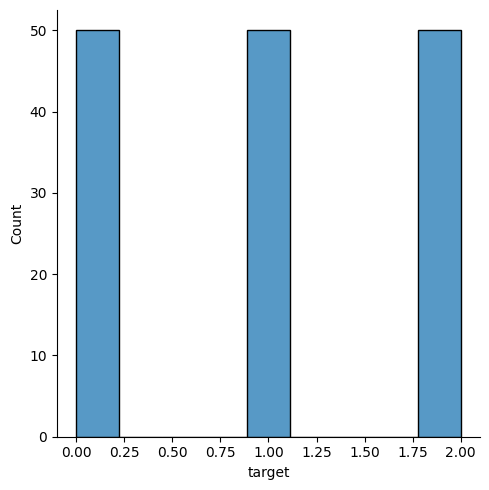

In [7]:
displot(ds_pandas,x = "target")

In [12]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(features, target, random_state=0, test_size = 0.30)

#Training the KNN Classifier without scaling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

for i in [1,3,5,7]:
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train, y_train)
  train_acc = knn.score(X_train, y_train)
  test_acc = knn.score(X_test, y_test)
  print(f"Neighbors: {i} | Training Accuracy: {train_acc:.4f} | Testing Accuracy: {test_acc:.4f}")

Neighbors: 1 | Training Accuracy: 1.0000 | Testing Accuracy: 0.9778
Neighbors: 3 | Training Accuracy: 0.9619 | Testing Accuracy: 0.9778
Neighbors: 5 | Training Accuracy: 0.9714 | Testing Accuracy: 0.9778
Neighbors: 7 | Training Accuracy: 0.9714 | Testing Accuracy: 0.9778


In [14]:
class_probability = knn.predict_proba(X_test)
print(class_probability)

[[0.         0.         1.        ]
 [0.         1.         0.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.85714286 0.14285714]
 [0.         1.         0.        ]
 [0.         0.14285714 0.85714286]
 [0.         1.         0.        ]
 [0.         0.85714286 0.14285714]
 [0.         0.85714286 0.14285714]
 [0.         0.71428571 0.28571429]
 [1.         0.         0.        ]
 [0.         0.85714286 0.14285714]
 [0.         1.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.14285714 0.85714286]
 [0.         1.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.28571429 0.71428571]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         1.         0.  

#Training the KNN classifier with Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

for i in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)
    print(f"Neighbors: {i} | Training Accuracy: {train_acc:.4f} | Testing Accuracy: {test_acc:.4f}")

Neighbors: 1 | Training Accuracy: 1.0000 | Testing Accuracy: 0.9333
Neighbors: 3 | Training Accuracy: 0.9714 | Testing Accuracy: 0.9778
Neighbors: 5 | Training Accuracy: 0.9714 | Testing Accuracy: 0.9778
Neighbors: 7 | Training Accuracy: 0.9714 | Testing Accuracy: 0.9778


In [16]:

class_probability = knn.predict_proba(X_test_scaled)
print(class_probability)

[[0.         0.         1.        ]
 [0.         0.85714286 0.14285714]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.85714286 0.14285714]
 [0.         1.         0.        ]
 [0.         0.14285714 0.85714286]
 [0.         1.         0.        ]
 [0.         0.85714286 0.14285714]
 [0.         0.71428571 0.28571429]
 [0.         0.71428571 0.28571429]
 [1.         0.         0.        ]
 [0.         0.71428571 0.28571429]
 [0.         1.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.14285714 0.85714286]
 [0.         1.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.85714286 0.14

#Plotting the Decision Boundaries on various K-Values

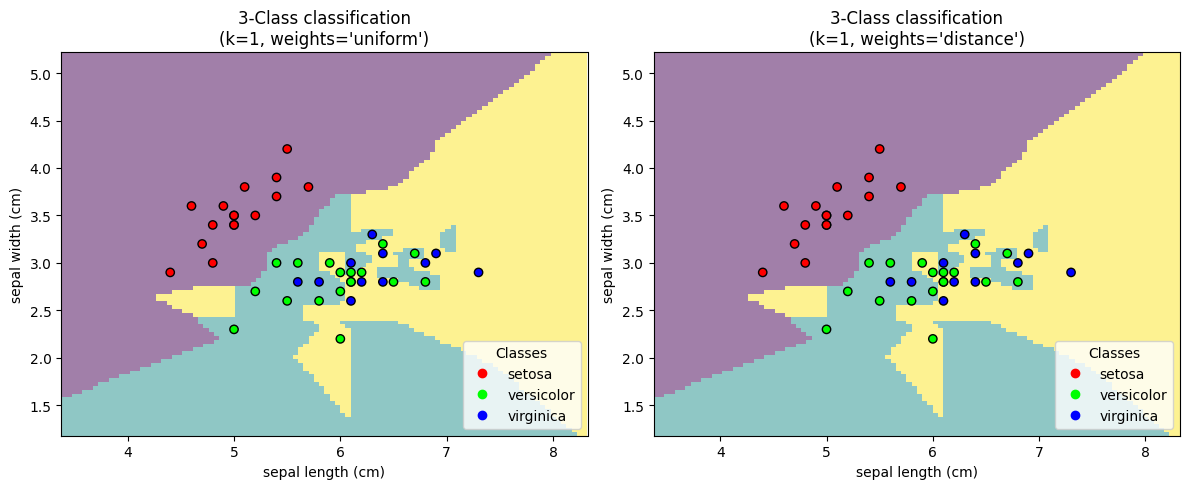

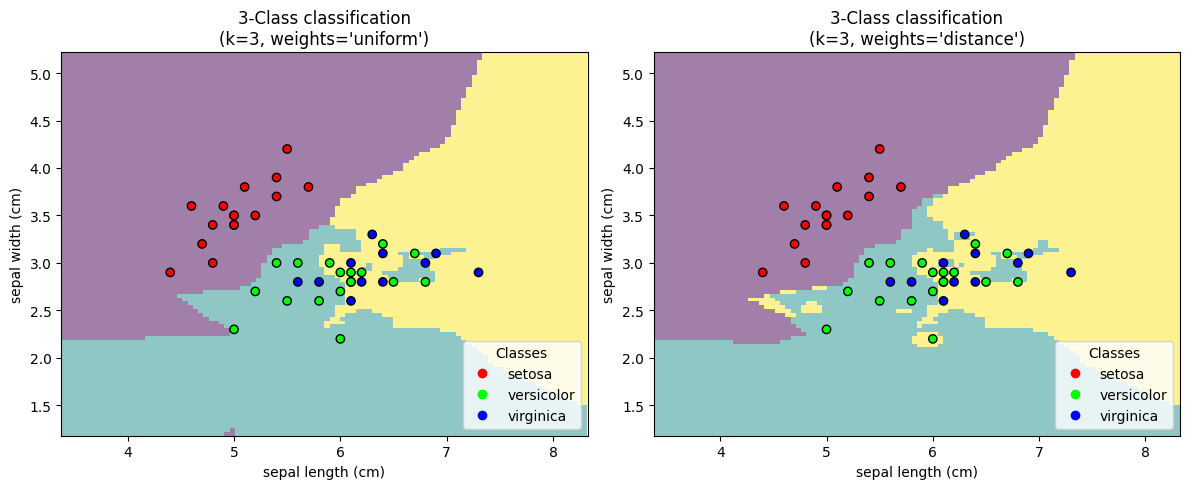

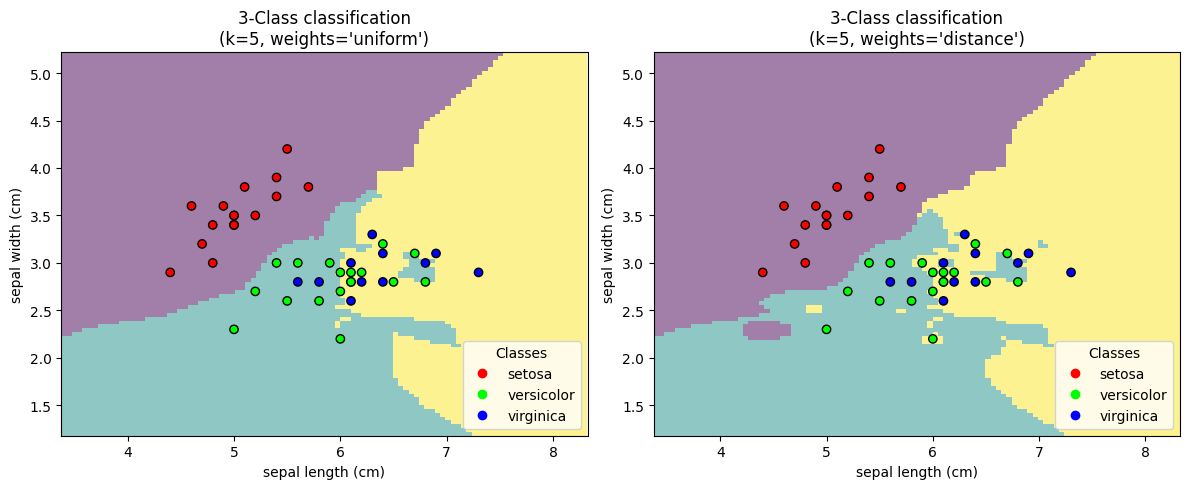

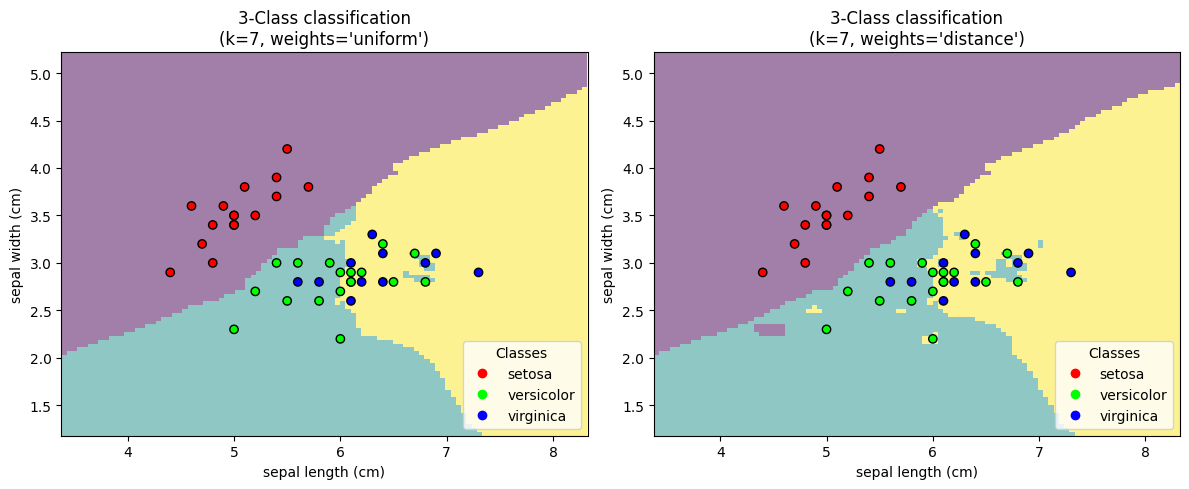

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline

X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]
for i in [1,3,5,7]:
  clf = Pipeline([
      ("scaler", StandardScaler()),
      ("knn", KNeighborsClassifier(n_neighbors=i))
  ])

  _, axs = plt.subplots(ncols=2, figsize=(12, 5))

  for ax, weights in zip(axs, ("uniform", "distance")):
      clf.set_params(knn__weights=weights).fit(X_train_2d, y_train)

      disp = DecisionBoundaryDisplay.from_estimator(
          clf,
          X_test_2d,
          response_method="predict",
          plot_method="pcolormesh",
          xlabel=dataset.feature_names[0],
          ylabel=dataset.feature_names[1],
          shading="auto",
          alpha=0.5,
          ax=ax,
      )

      scatter = ax.scatter(
          X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, edgecolors="k",
          cmap=mpl.colors.ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
      )

      ax.legend(
          scatter.legend_elements()[0],
          dataset.target_names,
          loc="lower right",
          title="Classes",
      )
      ax.set_title(
          f"3-Class classification\n(k={clf.named_steps['knn'].n_neighbors}, weights={weights!r})"
      )

  plt.tight_layout()
  plt.show()